In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(root="./data", train=True,  download=True, transform=transform)
test_dataset  = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

class_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

print("Train size:", len(train_dataset))
print("Test size: ", len(test_dataset))

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 7.70MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 11.8MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 23.6MB/s]

Train size: 60000
Test size:  10000


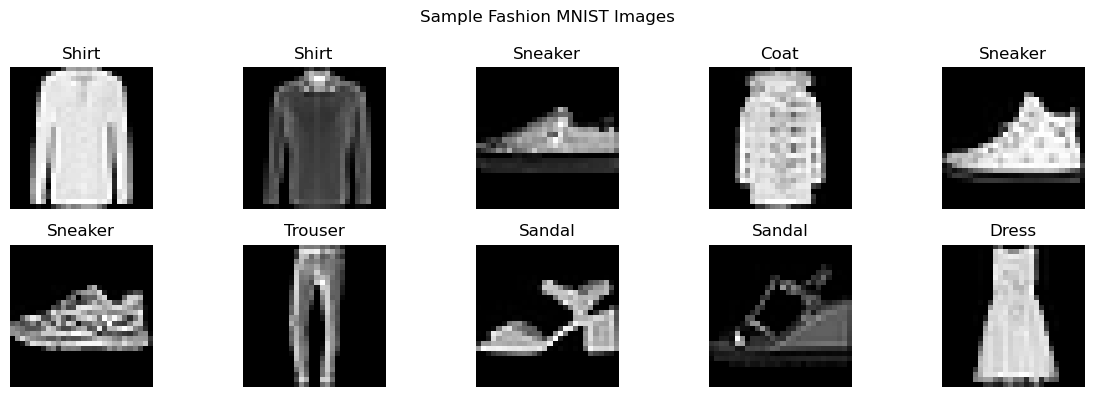

In [4]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    img = images[i].squeeze().numpy() * 0.5 + 0.5
    plt.imshow(img, cmap="gray")
    plt.title(class_names[labels[i]])
    plt.axis("off")
plt.suptitle("Sample Fashion MNIST Images")
plt.tight_layout()
plt.show()

In [5]:
class FashionCNN(nn.Module):
    def __init__(self):
        super(FashionCNN, self).__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )
        self.fc_block = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.fc_block(self.conv_block(x))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = FashionCNN().to(device)
print(model)
print("Device:", device)

FashionCNN(
  (conv_block): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
  )
  (fc_block): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=6272, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=10, bias=True)

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [7]:
EPOCHS = 15
train_losses, val_losses, train_accs, val_accs = [], [], [], []

for epoch in range(EPOCHS):
    model.train()
    running_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted  = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total   += labels.size(0)

    train_losses.append(running_loss / len(train_loader))
    train_accs.append(correct / total)

    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss    += loss.item()
            _, predicted = outputs.max(1)
            val_correct += predicted.eq(labels).sum().item()
            val_total   += labels.size(0)

    val_losses.append(val_loss / len(test_loader))
    val_accs.append(val_correct / val_total)

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Train Loss: {train_losses[-1]:.4f} | Train Acc: {train_accs[-1]:.4f} | Val Loss: {val_losses[-1]:.4f} | Val Acc: {val_accs[-1]:.4f}")

Epoch 01/15 | Train Loss: 0.4169 | Train Acc: 0.8518 | Val Loss: 0.2925 | Val Acc: 0.8905
Epoch 02/15 | Train Loss: 0.2860 | Train Acc: 0.8974 | Val Loss: 0.2647 | Val Acc: 0.9026
Epoch 03/15 | Train Loss: 0.2430 | Train Acc: 0.9112 | Val Loss: 0.2427 | Val Acc: 0.9088
Epoch 04/15 | Train Loss: 0.2129 | Train Acc: 0.9215 | Val Loss: 0.2275 | Val Acc: 0.9191
Epoch 05/15 | Train Loss: 0.1896 | Train Acc: 0.9311 | Val Loss: 0.2236 | Val Acc: 0.9215
Epoch 06/15 | Train Loss: 0.1647 | Train Acc: 0.9397 | Val Loss: 0.2194 | Val Acc: 0.9239
Epoch 07/15 | Train Loss: 0.1473 | Train Acc: 0.9452 | Val Loss: 0.2181 | Val Acc: 0.9243
Epoch 08/15 | Train Loss: 0.1301 | Train Acc: 0.9518 | Val Loss: 0.2255 | Val Acc: 0.9271
Epoch 09/15 | Train Loss: 0.1130 | Train Acc: 0.9574 | Val Loss: 0.2391 | Val Acc: 0.9271
Epoch 10/15 | Train Loss: 0.0976 | Train Acc: 0.9635 | Val Loss: 0.2606 | Val Acc: 0.9258
Epoch 11/15 | Train Loss: 0.0898 | Train Acc: 0.9661 | Val Loss: 0.2642 | Val Acc: 0.9220
Epoch 12/1

KeyboardInterrupt: 

In [ ]:
model.eval()
correct, total = 0, 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        _, predicted = model(images).max(1)
        correct += predicted.eq(labels).sum().item()
        total   += labels.size(0)

print(f"Test Accuracy: {correct / total * 100:.2f}%")

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses,   label="Val Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs,   label="Val Acc")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        _, predicted = model(images).max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
model.eval()
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    _, predicted = model(images).max(1)

plt.figure(figsize=(14, 6))
for i in range(10):
    plt.subplot(2, 5, i+1)
    img = images[i].cpu().squeeze().numpy() * 0.5 + 0.5
    plt.imshow(img, cmap="gray")
    pred   = class_names[predicted[i]]
    actual = class_names[labels[i]]
    color  = "green" if pred == actual else "red"
    plt.title(f"P: {pred}\nA: {actual}", color=color, fontsize=8)
    plt.axis("off")
plt.suptitle("Green = Correct | Red = Wrong")
plt.tight_layout()
plt.show()